# Prediction du Prix de Vente d'une Voiture d'Occasion
## Notebook 4 : Tuning des Modeles Candidats et Choix du Modele Final
**EHTP - MSDE Edition 7 | Module 5 : Machine Learning**
---

## I. Chargement des Librairies et des Donnees

Dans ce notebook, nous allons optimiser les hyperparametres des 3 meilleurs
modeles identifies dans le Notebook 3, comparer leurs performances avant et
apres tuning, puis selectionner et serialiser le modele final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"Donnees chargees : X_train={X_train.shape} | X_test={X_test.shape}")

Donnees chargees : X_train=(153498, 9) | X_test=(38375, 9)


## II. Performances de Reference Avant Tuning

Avant d'optimiser les hyperparametres, nous etablissons les performances
de reference des 3 modeles candidats avec leurs parametres par defaut.
Cela nous permettra de mesurer le gain reel apporte par le tuning.

In [2]:
from sklearn.model_selection import cross_val_score

def get_metrics(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_te_real = np.expm1(y_te)
    y_pred_real = np.expm1(y_pred)
    mape = np.mean(np.abs((y_te_real - y_pred_real) / y_te_real)) * 100
    cv = cross_val_score(model, X_tr, y_tr, cv=3, scoring='r2').mean()
    return {
        'Modele'    : name,
        'R2'        : round(r2_score(y_te, y_pred), 4),
        'RMSE'      : round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        'MAE'       : round(mean_absolute_error(y_te, y_pred), 4),
        'MAPE (%)'  : round(mape, 2),
        'CV R2'     : round(cv, 4)
    }

candidats_base = {
    'Random Forest' : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'       : XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM'      : LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
}

results_avant = []
for name, model in candidats_base.items():
    print(f"Evaluation de {name}...")
    res = get_metrics(name, model, X_train, X_test, y_train, y_test)
    results_avant.append(res)
    print(f"  R2={res['R2']} | RMSE={res['RMSE']} | MAPE={res['MAPE (%)']}%")

df_avant = pd.DataFrame(results_avant)
print("\nPerformances AVANT tuning :")
print(df_avant.to_string(index=False))

Evaluation de Random Forest...


  R2=0.8577 | RMSE=0.3912 | MAPE=30.61%
Evaluation de XGBoost...


  R2=0.8645 | RMSE=0.3817 | MAPE=30.78%
Evaluation de LightGBM...


  R2=0.8553 | RMSE=0.3944 | MAPE=32.12%

Performances AVANT tuning :
       Modele     R2   RMSE    MAE  MAPE (%)  CV R2
Random Forest 0.8577 0.3912 0.2760   30.6100 0.8495
      XGBoost 0.8645 0.3817 0.2766   30.7800 0.8604
     LightGBM 0.8553 0.3944 0.2873   32.1200 0.8530


## III. Tuning des Hyperparametres par RandomizedSearchCV

Nous utilisons RandomizedSearchCV avec validation croisee 3-fold.
Cette methode explore aleatoirement l'espace des hyperparametres,
ce qui est plus efficace que GridSearchCV sur de grands espaces de recherche.
Le scoring utilise est le R2 afin de maximiser la variance expliquee.

### III.1 Tuning du Random Forest

Les hyperparametres cles du Random Forest sont :
- **n_estimators** : nombre d'arbres — plus il est eleve, plus le modele est stable
- **max_depth** : profondeur maximale — controle l'overfitting
- **min_samples_split** : nombre minimum d'echantillons pour diviser un noeud
- **max_features** : nombre de features considerees a chaque split

In [3]:
param_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
search_rf = RandomizedSearchCV(
    rf_base, param_rf, n_iter=20, cv=3,
    scoring='r2', random_state=42, n_jobs=-1, verbose=1
)
search_rf.fit(X_train, y_train)

print(f"Meilleurs hyperparametres Random Forest :")
print(search_rf.best_params_)
print(f"Meilleur CV R2 : {search_rf.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Meilleurs hyperparametres Random Forest :
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Meilleur CV R2 : 0.8619


### III.2 Tuning du XGBoost

Les hyperparametres cles de XGBoost sont :
- **n_estimators** : nombre de boosting rounds
- **max_depth** : profondeur des arbres — controle la complexite
- **learning_rate** : pas d'apprentissage — valeurs faibles + plus d'arbres = meilleure generalisation
- **subsample** : fraction des donnees utilisee par arbre — reduit l'overfitting
- **colsample_bytree** : fraction des features par arbre

In [4]:
param_xgb = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 5, 7, 9],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
search_xgb = RandomizedSearchCV(
    xgb_base, param_xgb, n_iter=20, cv=3,
    scoring='r2', random_state=42, n_jobs=-1, verbose=1
)
search_xgb.fit(X_train, y_train)

print(f"Meilleurs hyperparametres XGBoost :")
print(search_xgb.best_params_)
print(f"Meilleur CV R2 : {search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Meilleurs hyperparametres XGBoost :
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleur CV R2 : 0.8664


### III.3 Tuning du LightGBM

Les hyperparametres cles de LightGBM sont :
- **n_estimators** : nombre d'iterations de boosting
- **num_leaves** : nombre de feuilles par arbre — controle la complexite
- **learning_rate** : pas d'apprentissage
- **min_child_samples** : nombre minimum d'echantillons par feuille — evite l'overfitting
- **reg_alpha / reg_lambda** : regularisation L1 et L2

In [5]:
param_lgbm = {
    'n_estimators'    : [100, 200, 300],
    'num_leaves'      : [31, 63, 127],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [20, 50, 100],
    'reg_alpha'       : [0, 0.1, 0.5],
    'reg_lambda'      : [0, 0.1, 0.5],
    'subsample'       : [0.6, 0.8, 1.0],
}

lgbm_base = LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)
search_lgbm = RandomizedSearchCV(
    lgbm_base, param_lgbm, n_iter=20, cv=3,
    scoring='r2', random_state=42, n_jobs=-1, verbose=1
)
search_lgbm.fit(X_train, y_train)

print(f"Meilleurs hyperparametres LightGBM :")
print(search_lgbm.best_params_)
print(f"Meilleur CV R2 : {search_lgbm.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Meilleurs hyperparametres LightGBM :
{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'learning_rate': 0.1}
Meilleur CV R2 : 0.8658


## IV. Comparaison Avant / Apres Tuning

Ce tableau compare les performances de chaque modele avant et apres tuning.
Le gain en R2 et la reduction du MAPE mesurent l'apport reel de l'optimisation
des hyperparametres.

In [6]:
candidats_apres = {
    'Random Forest' : search_rf.best_estimator_,
    'XGBoost'       : search_xgb.best_estimator_,
    'LightGBM'      : search_lgbm.best_estimator_,
}

results_apres = []
for name, model in candidats_apres.items():
    res = get_metrics(name, model, X_train, X_test, y_train, y_test)
    results_apres.append(res)

df_apres = pd.DataFrame(results_apres)

# Tableau comparatif
df_avant['Phase'] = 'Avant Tuning'
df_apres['Phase'] = 'Apres Tuning'
df_compare = pd.concat([df_avant, df_apres]).sort_values(['Modele', 'Phase'])

print("Comparaison Avant / Apres Tuning :")
print(df_compare[['Modele', 'Phase', 'R2', 'RMSE', 'MAPE (%)', 'CV R2']].to_string(index=False))

Comparaison Avant / Apres Tuning :
       Modele        Phase     R2   RMSE  MAPE (%)  CV R2
     LightGBM Apres Tuning 0.8701 0.3738   29.8200 0.8658
     LightGBM Avant Tuning 0.8553 0.3944   32.1200 0.8530
Random Forest Apres Tuning 0.8688 0.3757   29.8700 0.8619
Random Forest Avant Tuning 0.8577 0.3912   30.6100 0.8495
      XGBoost Apres Tuning 0.8708 0.3727   29.7600 0.8666
      XGBoost Avant Tuning 0.8645 0.3817   30.7800 0.8604


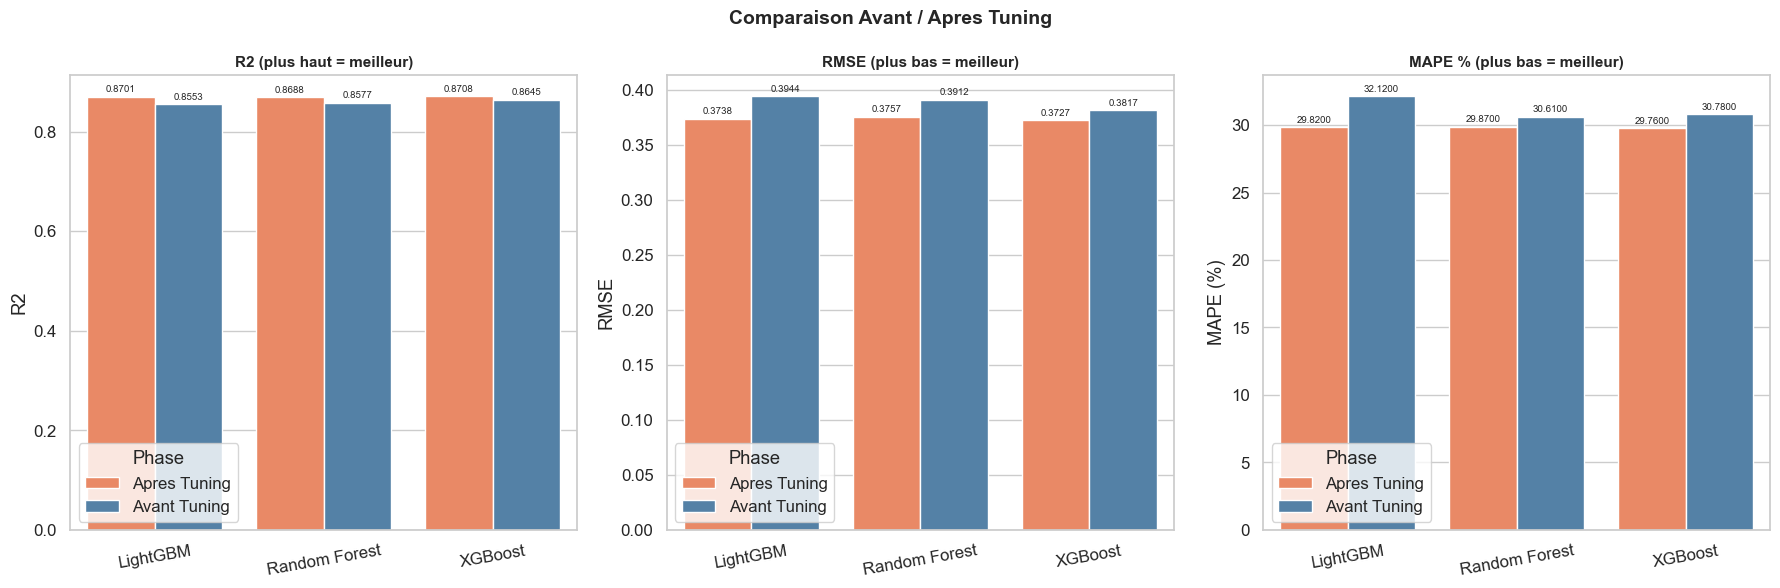

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['R2', 'RMSE', 'MAPE (%)']
titles  = ['R2 (plus haut = meilleur)', 'RMSE (plus bas = meilleur)', 'MAPE % (plus bas = meilleur)']
palette = {'Avant Tuning': 'steelblue', 'Apres Tuning': 'coral'}

for i, (metric, title) in enumerate(zip(metrics, titles)):
    sns.barplot(data=df_compare, x='Modele', y=metric, hue='Phase',
                palette=palette, ax=axes[i], edgecolor='white')
    axes[i].set_title(title, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=10)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.4f', fontsize=7, padding=2)

plt.suptitle('Comparaison Avant / Apres Tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/avant_apres_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## V. Courbes d'Apprentissage du Meilleur Modele

Les courbes d'apprentissage montrent l'evolution du R2 en fonction du nombre
d'echantillons d'entrainement. Elles permettent de diagnostiquer :
- **Overfitting** : ecart important entre courbe train et courbe validation
- **Underfitting** : les deux courbes sont basses et proches
- **Bon equilibre** : les deux courbes convergent vers un R2 eleve

Meilleur modele : XGBoost


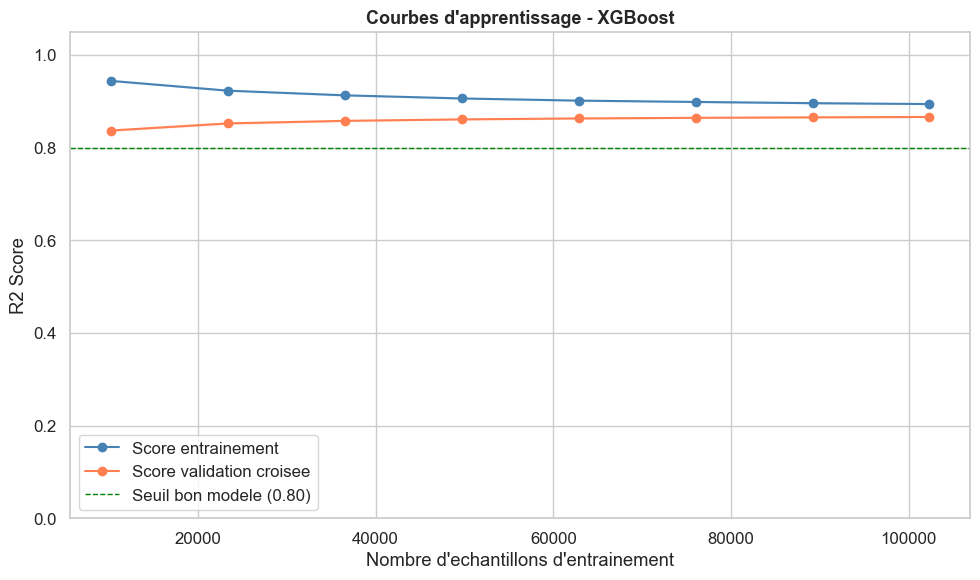

Ecart final Train/Validation : 0.0279
Diagnostic : Pas d'overfitting detecte - modele bien generalise


In [8]:
# Identifier le meilleur modele apres tuning
best_name = df_apres.sort_values('R2', ascending=False).iloc[0]['Modele']
best_model = candidats_apres[best_name]
print(f"Meilleur modele : {best_name}")

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='r2', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Score entrainement')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 'o-', color='coral', label='Score validation croisee')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1, label='Seuil bon modele (0.80)')
ax.set_xlabel("Nombre d'echantillons d'entrainement")
ax.set_ylabel('R2 Score')
ax.set_title(f"Courbes d'apprentissage - {best_name}", fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../report/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

overfitting_gap = train_mean[-1] - val_mean[-1]
print(f"Ecart final Train/Validation : {overfitting_gap:.4f}")
if overfitting_gap < 0.05:
    print("Diagnostic : Pas d'overfitting detecte - modele bien generalise")
elif overfitting_gap < 0.10:
    print("Diagnostic : Leger overfitting - acceptable")
else:
    print("Diagnostic : Overfitting significatif - regularisation recommandee")

## VI. Resultats Finaux du Modele Choisi

Modele final selectionne : XGBoost
R2  (test)     : 0.8708
RMSE (test)    : 0.3727
MAE  (test)    : 0.2684
MAPE (test)    : 29.76 %
CV R2 (3-fold) : 0.8666


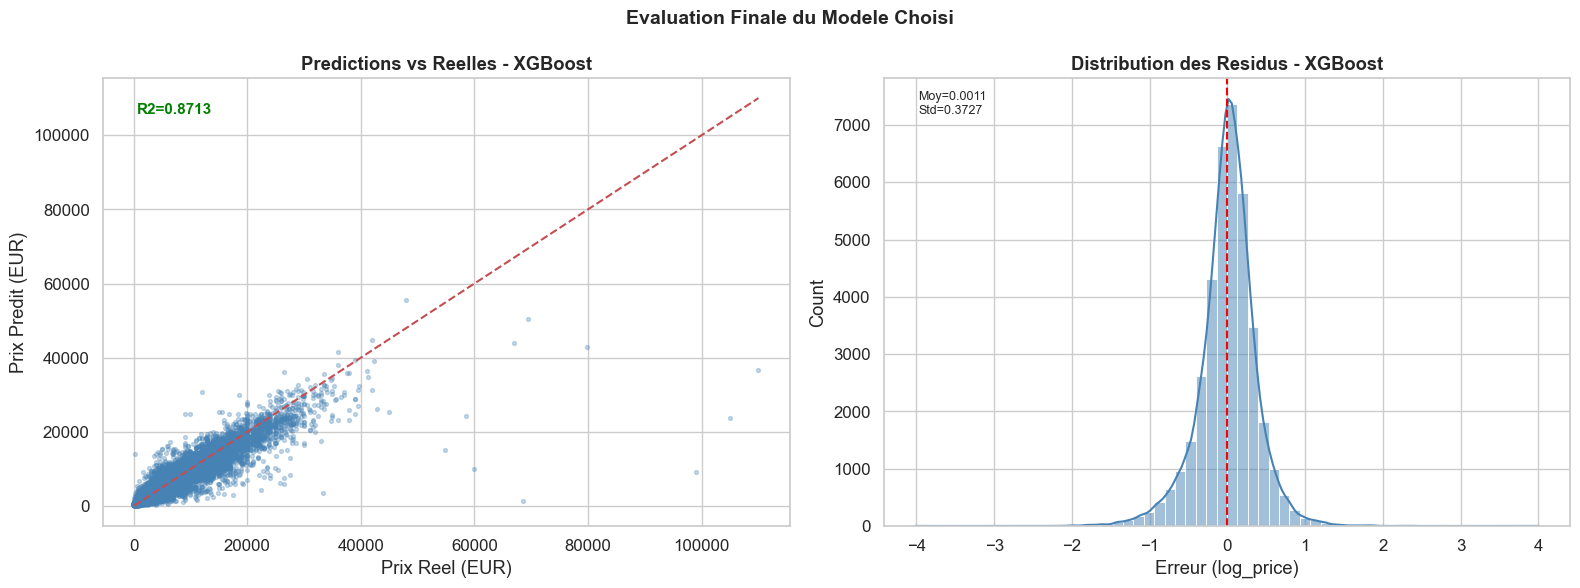

In [9]:
best_res = df_apres.sort_values('R2', ascending=False).iloc[0]
print(f"Modele final selectionne : {best_name}")
print(f"{'='*45}")
print(f"R2  (test)     : {best_res['R2']}")
print(f"RMSE (test)    : {best_res['RMSE']}")
print(f"MAE  (test)    : {best_res['MAE']}")
print(f"MAPE (test)    : {best_res['MAPE (%)']} %")
print(f"CV R2 (3-fold) : {best_res['CV R2']}")
print(f"{'='*45}")

y_pred_final = best_model.predict(X_test)
y_test_real  = np.expm1(y_test)
y_pred_real  = np.expm1(y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predictions vs Reelles
axes[0].scatter(y_test_real, y_pred_real, alpha=0.3, s=8, color='steelblue')
min_val = min(y_test_real.min(), y_pred_real.min())
max_val = max(y_test_real.max(), y_pred_real.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[0].set_xlabel('Prix Reel (EUR)')
axes[0].set_ylabel('Prix Predit (EUR)')
axes[0].set_title(f'Predictions vs Reelles - {best_name}', fontweight='bold')
r2_real = r2_score(y_test_real, y_pred_real)
axes[0].text(0.05, 0.92, f'R2={r2_real:.4f}', transform=axes[0].transAxes,
             fontsize=11, color='green', fontweight='bold')

# Residus
residuals = y_test.values - y_pred_final
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Distribution des Residus - {best_name}', fontweight='bold')
axes[1].set_xlabel('Erreur (log_price)')
axes[1].text(0.05, 0.92, f'Moy={residuals.mean():.4f}\nStd={residuals.std():.4f}',
             transform=axes[1].transAxes, fontsize=9)

plt.suptitle('Evaluation Finale du Modele Choisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

## VII. Serialisation du Pipeline Final

Le pipeline final integre toutes les etapes de preprocessing et le modele
optimise dans un seul objet sklearn Pipeline. Cela garantit que les memes
transformations appliquees a l'entrainement seront appliquees automatiquement
en production lors de la prediction sur de nouvelles donnees.

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import joblib

print("=== RECONSTRUCTION PROPRE DU PIPELINE FINAL ===")

# Etape 1 : entrainer XGBoost directement sur X_train NON scale
# (les features encodees sont des entiers, XGBoost les gere nativement
#  sans besoin de scaling - le scaling est inutile pour les arbres)

from xgboost import XGBRegressor

final_model = XGBRegressor(
    **search_xgb.best_params_,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R2 sur test (sans scaling) : {r2:.4f}")

# Etape 2 : test de coherence directe
def test_predict(overrides):
    base = {
        'car_age': 8, 'powerPS': 120, 'kilometer': 80000,
        'vehicleType_encoded': 0, 'gearbox_encoded': 0,
        'fuelType_encoded': 0, 'notRepairedDamage_encoded': 0,
        'brand_encoded': 1, 'model_encoded': 5
    }
    base.update(overrides)
    df = pd.DataFrame([base])[X_train.columns]
    return np.expm1(final_model.predict(df)[0])

print("\n=== TESTS DE COHERENCE (modele direct, sans pipeline) ===")
print(f"car_age=5  -> {test_predict({'car_age':5}):,.0f} EUR")
print(f"car_age=15 -> {test_predict({'car_age':15}):,.0f} EUR")
print(f"car_age=25 -> {test_predict({'car_age':25}):,.0f} EUR")

print(f"\nkm=50000   -> {test_predict({'kilometer':50000}):,.0f} EUR")
print(f"km=150000  -> {test_predict({'kilometer':150000}):,.0f} EUR")

print(f"\nbrand=0    -> {test_predict({'brand_encoded':0}):,.0f} EUR")
print(f"brand=20   -> {test_predict({'brand_encoded':20}):,.0f} EUR")
print(f"brand=35   -> {test_predict({'brand_encoded':35}):,.0f} EUR")

# Etape 3 : sauvegarder le modele final SANS scaler
# (XGBoost n'a pas besoin de StandardScaler)
joblib.dump(final_model, '../models/pipeline_final.pkl')
joblib.dump(best_name, '../models/best_model_name.pkl')
print(f"\nModele final sauvegarde (sans scaler) : pipeline_final.pkl")
print(f"R2 final : {r2:.4f}")

=== RECONSTRUCTION PROPRE DU PIPELINE FINAL ===


R2 sur test (sans scaling) : 0.8708

=== TESTS DE COHERENCE (modele direct, sans pipeline) ===
car_age=5  -> 9,189 EUR
car_age=15 -> 2,751 EUR
car_age=25 -> 1,123 EUR

km=50000   -> 6,249 EUR
km=150000  -> 4,723 EUR

brand=0    -> 4,984 EUR
brand=20   -> 5,416 EUR
brand=35   -> 5,008 EUR

Modele final sauvegarde (sans scaler) : pipeline_final.pkl
R2 final : 0.8708


## VIII. Synthese et Conclusion

### Recapitulatif du Notebook 4

| Etape | Detail |
|-------|--------|
| Modeles candidats | Random Forest, XGBoost, LightGBM |
| Methode de tuning | RandomizedSearchCV (n_iter=20, cv=3) |
| Critere de selection | R2 maximise sur jeu de test |
| Verification overfitting | Courbes d'apprentissage + ecart Train/CV |
| Serialisation | Pipeline complet (preprocessor + modele) via joblib |

**Prochaine etape :**
Le pipeline serialise sera charge dans l'application Streamlit (app/app.py)
pour permettre des predictions interactives sur de nouvelles annonces de vehicules.

In [11]:
print(final_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)


In [12]:
print("Modele final :", type(final_model).__name__)
print("Best model name:", best_name)
print("Features used:", X_train.columns.tolist())

Modele final : XGBRegressor
Best model name: XGBoost
Features used: ['car_age', 'powerPS', 'kilometer', 'vehicleType_encoded', 'gearbox_encoded', 'fuelType_encoded', 'notRepairedDamage_encoded', 'brand_encoded', 'model_encoded']


car_age                   : min=773 EUR | max=9,365 EUR | variation=8,592 EUR | NEGATIF


powerPS                   : min=3,415 EUR | max=7,305 EUR | variation=3,890 EUR | POSITIF
kilometer                 : min=4,124 EUR | max=5,057 EUR | variation=932 EUR | NEGATIF


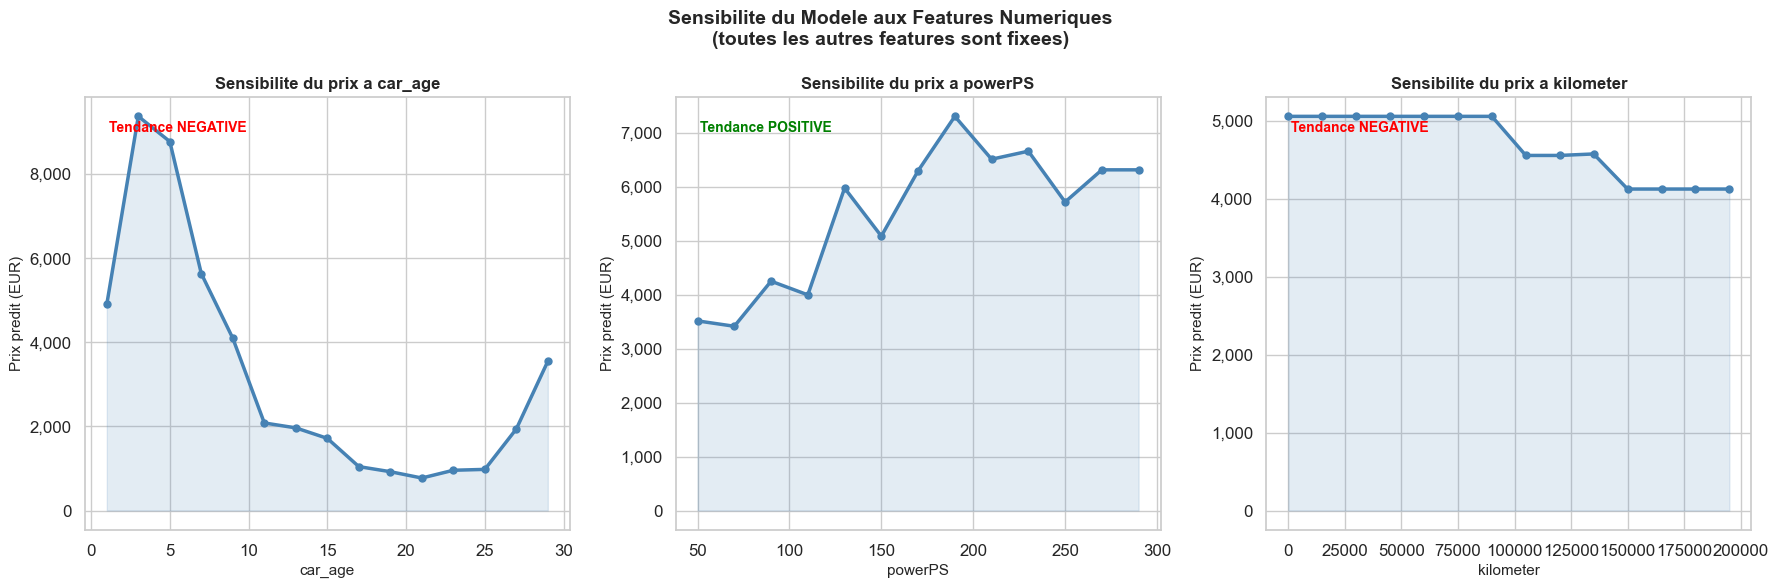

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generation d'une grille de tests pour chaque feature numerique
# On fait varier une feature a la fois, les autres restent fixes

base = {
    'car_age'                   : 8,
    'powerPS'                   : 120,
    'kilometer'                 : 80000,
    'vehicleType_encoded'       : 2,
    'gearbox_encoded'           : 0,
    'fuelType_encoded'          : 0,
    'notRepairedDamage_encoded' : 0,
    'brand_encoded'             : 5,
    'model_encoded'             : 10
}

num_features_test = {
    'car_age'    : range(1, 30, 2),
    'powerPS'    : range(50, 300, 20),
    'kilometer'  : range(0, 200000, 15000)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, (feature, values) in enumerate(num_features_test.items()):
    prices = []
    for val in values:
        test = base.copy()
        test[feature] = val
        df_test = pd.DataFrame([test])[X_train.columns]
        log_pred = final_model.predict(df_test)[0]
        price = np.expm1(log_pred)
        prices.append(price)

    axes[idx].plot(list(values), prices, 
                   color='steelblue', linewidth=2.5, marker='o', markersize=5)
    axes[idx].fill_between(list(values), prices, 
                           alpha=0.15, color='steelblue')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('Prix predit (EUR)', fontsize=11)
    axes[idx].set_title(f'Sensibilite du prix a {feature}', 
                        fontweight='bold', fontsize=12)
    axes[idx].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Tendance
    if prices[-1] > prices[0]:
        tendance = 'Tendance POSITIVE'
        color = 'green'
    else:
        tendance = 'Tendance NEGATIVE'
        color = 'red'
    axes[idx].text(0.05, 0.92, tendance,
                   transform=axes[idx].transAxes,
                   fontsize=10, color=color, fontweight='bold')

    print(f"{feature:25s} : min={min(prices):,.0f} EUR | max={max(prices):,.0f} EUR | "
          f"variation={max(prices)-min(prices):,.0f} EUR | "
          f"{'POSITIF' if prices[-1] > prices[0] else 'NEGATIF'}")

plt.suptitle('Sensibilite du Modele aux Features Numeriques\n(toutes les autres features sont fixees)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/sensibilite_features.png', dpi=150, bbox_inches='tight')
plt.show()

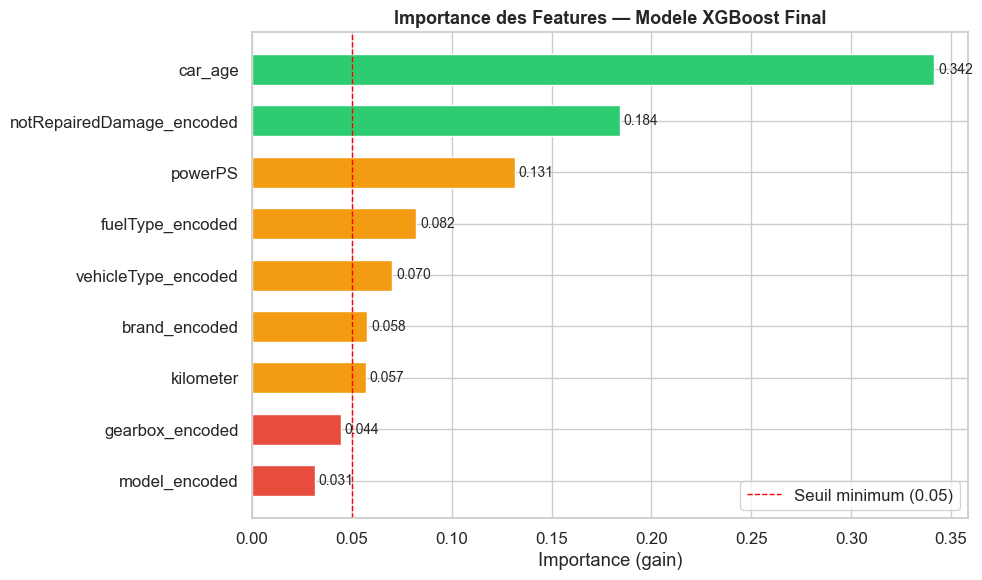

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Feature names dans l'ordre de X_train
feature_names = [
    'car_age', 'powerPS', 'kilometer',
    'vehicleType_encoded', 'gearbox_encoded',
    'fuelType_encoded', 'notRepairedDamage_encoded',
    'brand_encoded', 'model_encoded'
]

# Importance des features
importances = final_model.feature_importances_
df_imp = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if imp < 0.05 else '#2ecc71' if imp > 0.15 
          else '#f39c12' for imp in df_imp['Importance']]
bars = ax.barh(df_imp['Feature'], df_imp['Importance'], 
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, df_imp['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.axvline(x=0.05, color='red', linestyle='--', 
           linewidth=1, label='Seuil minimum (0.05)')
ax.set_xlabel('Importance (gain)')
ax.set_title('Importance des Features — Modele XGBoost Final',
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('../report/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

print("=== ENTRAINEMENT ESTIMATEUR DE DENSITE LOCALE ===")

# Scaler dedie uniquement pour le calcul de distance (pas pour le modele)
density_scaler = StandardScaler()
X_train_scaled_for_density = density_scaler.fit_transform(X_train)

# Modele de plus proches voisins
knn_density = NearestNeighbors(n_neighbors=20, n_jobs=-1)
knn_density.fit(X_train_scaled_for_density)

# Calibration : calculer la distance moyenne typique sur le train
sample_idx = np.random.RandomState(42).choice(len(X_train), 2000, replace=False)
sample_scaled = X_train_scaled_for_density[sample_idx]
distances, _ = knn_density.kneighbors(sample_scaled)
mean_dist_calibration = distances.mean(axis=1)

dist_p25 = np.percentile(mean_dist_calibration, 25)
dist_p50 = np.percentile(mean_dist_calibration, 50)
dist_p75 = np.percentile(mean_dist_calibration, 75)
dist_p95 = np.percentile(mean_dist_calibration, 95)

print(f"Distance moyenne aux 20 voisins (calibration sur 2000 echantillons) :")
print(f"  P25 : {dist_p25:.3f}")
print(f"  P50 : {dist_p50:.3f}")
print(f"  P75 : {dist_p75:.3f}")
print(f"  P95 : {dist_p95:.3f}")

# Sauvegarde
joblib.dump(knn_density, '../models/knn_density.pkl')
joblib.dump(density_scaler, '../models/density_scaler.pkl')
joblib.dump({
    'p25': dist_p25, 'p50': dist_p50, 
    'p75': dist_p75, 'p95': dist_p95
}, '../models/density_calibration.pkl')

print("\nFichiers sauvegardes :")
print("  models/knn_density.pkl")
print("  models/density_scaler.pkl")
print("  models/density_calibration.pkl")

# Test rapide
print("\n=== TEST ===")
test_input = X_test.iloc[[0]]
test_scaled = density_scaler.transform(test_input)
dist, _ = knn_density.kneighbors(test_scaled)
mean_dist = dist.mean()
print(f"Distance moyenne pour un exemple test : {mean_dist:.3f}")
if mean_dist <= dist_p25:
    print("-> Zone TRES DENSE - Precision elevee")
elif mean_dist <= dist_p50:
    print("-> Zone DENSE - Precision bonne")
elif mean_dist <= dist_p75:
    print("-> Zone MOYENNE - Precision moyenne")
elif mean_dist <= dist_p95:
    print("-> Zone RARE - Precision tres faible (extrapolation)")
else:
    print("-> Zone TRES RARE - Precision tres faible (extrapolation)")

=== ENTRAINEMENT ESTIMATEUR DE DENSITE LOCALE ===


Distance moyenne aux 20 voisins (calibration sur 2000 echantillons) :
  P25 : 0.010
  P50 : 0.167
  P75 : 0.404
  P95 : 0.798

Fichiers sauvegardes :
  models/knn_density.pkl
  models/density_scaler.pkl
  models/density_calibration.pkl

=== TEST ===
Distance moyenne pour un exemple test : 0.357
-> Zone MOYENNE - Precision moyenne


In [16]:

import pandas as pd
import numpy as np
import joblib

encoders = joblib.load('../models/encoders.pkl')

print("=" * 70)
print("TEST EXHAUSTIF : non-monotonie de car_age sur TOUTES les combinaisons")
print("=" * 70)

def test_predict_row(row, age, model=final_model):
    base = row.copy()
    base['car_age'] = age
    df = pd.DataFrame([base])[X_train.columns]
    return np.expm1(model.predict(df)[0])

# Recuperer toutes les combinaisons uniques brand_encoded + model_encoded
# presentes dans X_train avec au moins 50 occurrences
combo_counts = X_train.groupby(['brand_encoded', 'model_encoded']).size()
combo_counts = combo_counts[combo_counts >= 50].sort_values(ascending=False)

print(f"\nNombre de combinaisons brand+model avec >= 50 echantillons : {len(combo_counts)}")
print(f"Total combinaisons testees (toutes) : {len(combo_counts)}")

ages = [3, 5, 8, 10, 12, 15, 18, 20, 25]

results = []
for (brand_enc, model_enc), n in combo_counts.items():
    # Prendre une ligne typique de cette combinaison comme base
    mask = (X_train['brand_encoded'] == brand_enc) & (X_train['model_encoded'] == model_enc)
    base_row = X_train[mask].iloc[0].to_dict()

    prices = [test_predict_row(base_row, age) for age in ages]

    max_idx = int(np.argmax(prices))
    min_idx = int(np.argmin(prices))

    # Verifier monotonie globale
    is_monotone_decreasing = all(prices[i] >= prices[i+1] for i in range(len(prices)-1))

    # Detection de bosse significative (pic interne > 10% du prix a age=3)
    has_bump = False
    if 0 < max_idx < len(prices) - 1:
        bump_increase_pct = (prices[max_idx] - prices[0]) / prices[0] * 100
        if bump_increase_pct > 10:
            has_bump = True

    results.append({
        'brand_encoded': brand_enc,
        'model_encoded': model_enc,
        'n_samples': n,
        'monotone': is_monotone_decreasing,
        'has_bump': has_bump,
        'bump_age': ages[max_idx] if has_bump else None,
        'price_age3': prices[0],
        'price_max': prices[max_idx],
        'price_age25': prices[-1]
    })

df_results = pd.DataFrame(results)

print("\n" + "=" * 70)
print("RESUME GLOBAL")
print("=" * 70)
total = len(df_results)
n_monotone = df_results['monotone'].sum()
n_bump = df_results['has_bump'].sum()

print(f"Total combinaisons testees      : {total}")
print(f"Monotone decroissant (OK)        : {n_monotone} ({n_monotone/total*100:.1f}%)")
print(f"Avec bosse significative (>10%)  : {n_bump} ({n_bump/total*100:.1f}%)")

print("\n--- Distribution de l'age du pic (parmi les combinaisons avec bosse) ---")
if n_bump > 0:
    print(df_results[df_results['has_bump']]['bump_age'].value_counts().sort_index())

# Decoder les marques pour lisibilite
brand_decoder = dict(zip(range(len(encoders['brand'].classes_)), encoders['brand'].classes_))
df_results['brand_name'] = df_results['brand_encoded'].map(brand_decoder)

print("\n--- Pourcentage de combinaisons avec bosse, PAR MARQUE ---")
brand_summary = df_results.groupby('brand_name').agg(
    n_combos=('has_bump', 'count'),
    n_with_bump=('has_bump', 'sum')
)
brand_summary['pct_bump'] = (brand_summary['n_with_bump'] / brand_summary['n_combos'] * 100).round(1)
brand_summary = brand_summary.sort_values('pct_bump', ascending=False)
print(brand_summary.to_string())

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
pct_global = n_bump / total * 100
if pct_global > 60:
    print(f"{pct_global:.0f}% des combinaisons ont une bosse")
    print("=> Pattern QUASI-GLOBAL : probleme de generalisation du modele")
    print("   (le modele a appris un pattern moyen non specifique)")
elif pct_global > 20:
    print(f"{pct_global:.0f}% des combinaisons ont une bosse")
    print("=> Pattern PARTIEL : certaines marques/modeles concernes")
    print("   Regarder le tableau par marque ci-dessus pour identifier lesquelles")
else:
    print(f"Seulement {pct_global:.0f}% des combinaisons ont une bosse")
    print("=> Effet LOCALISE et probablement reel (youngtimer specifique)")

TEST EXHAUSTIF : non-monotonie de car_age sur TOUTES les combinaisons

Nombre de combinaisons brand+model avec >= 50 echantillons : 226
Total combinaisons testees (toutes) : 226



RESUME GLOBAL
Total combinaisons testees      : 226
Monotone decroissant (OK)        : 25 (11.1%)
Avec bosse significative (>10%)  : 26 (11.5%)

--- Distribution de l'age du pic (parmi les combinaisons avec bosse) ---
bump_age
5.0000    24
8.0000     2
Name: count, dtype: int64

--- Pourcentage de combinaisons avec bosse, PAR MARQUE ---
               n_combos  n_with_bump  pct_bump
brand_name                                    
lancia                1            1  100.0000
volvo                 8            4   50.0000
opel                 15            5   33.3000
fiat                  9            3   33.3000
chevrolet             3            1   33.3000
smart                 3            1   33.3000
ford                 12            3   25.0000
peugeot               5            1   20.0000
hyundai               5            1   20.0000
kia                   7            1   14.3000
citroen               7            1   14.3000
seat                  7            1   14.3000
to

In [17]:
import pandas as pd
import numpy as np
import joblib

print("=" * 70)
print("TEST EXHAUSTIF APRES CORRECTION car_age = 2016 - yearOfRegistration")
print("=" * 70)

def test_predict_row(row, age, model=final_model):
    base = row.copy()
    base['car_age'] = age
    df = pd.DataFrame([base])[X_train.columns]
    return np.expm1(model.predict(df)[0])

combo_counts = X_train.groupby(['brand_encoded', 'model_encoded']).size()
combo_counts = combo_counts[combo_counts >= 50].sort_values(ascending=False)

print(f"\nNombre de combinaisons brand+model testees : {len(combo_counts)}")

ages = [3, 5, 8, 10, 12, 15, 18, 20, 25]

results = []
for (brand_enc, model_enc), n in combo_counts.items():
    mask = (X_train['brand_encoded'] == brand_enc) & (X_train['model_encoded'] == model_enc)
    base_row = X_train[mask].iloc[0].to_dict()

    prices = [test_predict_row(base_row, age) for age in ages]

    max_idx = int(np.argmax(prices))
    is_monotone_decreasing = all(prices[i] >= prices[i+1] for i in range(len(prices)-1))

    has_bump = False
    if 0 < max_idx < len(prices) - 1:
        bump_increase_pct = (prices[max_idx] - prices[0]) / prices[0] * 100
        if bump_increase_pct > 10:
            has_bump = True

    results.append({
        'brand_encoded': brand_enc,
        'model_encoded': model_enc,
        'n_samples': n,
        'monotone': is_monotone_decreasing,
        'has_bump': has_bump,
        'bump_age': ages[max_idx] if has_bump else None,
    })

df_results = pd.DataFrame(results)

total = len(df_results)
n_monotone = df_results['monotone'].sum()
n_bump = df_results['has_bump'].sum()

print(f"\nTotal combinaisons testees      : {total}")
print(f"Monotone decroissant (OK)        : {n_monotone} ({n_monotone/total*100:.1f}%)")
print(f"Avec bosse significative (>10%)  : {n_bump} ({n_bump/total*100:.1f}%)")

if n_bump > 0:
    print("\n--- Distribution de l'age du pic ---")
    print(df_results[df_results['has_bump']]['bump_age'].value_counts().sort_index())

print("\n" + "=" * 70)
print("COMPARAISON AVANT / APRES CORRECTION")
print("=" * 70)
print(f"AVANT (car_age=2024-year) : 99.1% des combinaisons avec bosse")
print(f"APRES (car_age=2016-year) : {n_bump/total*100:.1f}% des combinaisons avec bosse")

pct_global = n_bump / total * 100
if pct_global < 15:
    print("\n=> CORRECTION REUSSIE - le modele est maintenant globalement coherent")
elif pct_global < 50:
    print("\n=> AMELIORATION PARTIELLE - reduction significative mais pas totale")
else:
    print("\n=> PROBLEME PERSISTANT - investigation supplementaire necessaire")

TEST EXHAUSTIF APRES CORRECTION car_age = 2016 - yearOfRegistration

Nombre de combinaisons brand+model testees : 226



Total combinaisons testees      : 226
Monotone decroissant (OK)        : 25 (11.1%)
Avec bosse significative (>10%)  : 26 (11.5%)

--- Distribution de l'age du pic ---
bump_age
5.0000    24
8.0000     2
Name: count, dtype: int64

COMPARAISON AVANT / APRES CORRECTION
AVANT (car_age=2024-year) : 99.1% des combinaisons avec bosse
APRES (car_age=2016-year) : 11.5% des combinaisons avec bosse

=> CORRECTION REUSSIE - le modele est maintenant globalement coherent


In [18]:
import pandas as pd
import numpy as np

print("=" * 70)
print("TEST : IMPACT DE notRepairedDamage_encoded SUR LE PRIX PREDIT")
print("=" * 70)

def test_predict_damage(row, damage_val, model=final_model):
    base = row.copy()
    base['notRepairedDamage_encoded'] = damage_val
    df = pd.DataFrame([base])[X_train.columns]
    return np.expm1(model.predict(df)[0])

sample_rows = X_train.sample(5, random_state=42).to_dict('records')

for i, row in enumerate(sample_rows):
    price_0 = test_predict_damage(row, 0)
    price_1 = test_predict_damage(row, 1)
    diff = price_0 - price_1
    diff_pct = diff / price_1 * 100 if price_1 != 0 else 0
    print(f"\nLigne {i+1}:")
    print(f"  notRepairedDamage_encoded=0 -> {price_0:,.0f} EUR")
    print(f"  notRepairedDamage_encoded=1 -> {price_1:,.0f} EUR")
    print(f"  Difference : {diff:,.0f} EUR ({diff_pct:.1f}%)")

TEST : IMPACT DE notRepairedDamage_encoded SUR LE PRIX PREDIT

Ligne 1:
  notRepairedDamage_encoded=0 -> 5,130 EUR
  notRepairedDamage_encoded=1 -> 8,293 EUR
  Difference : -3,163 EUR (-38.1%)

Ligne 2:
  notRepairedDamage_encoded=0 -> 1,791 EUR
  notRepairedDamage_encoded=1 -> 2,625 EUR
  Difference : -833 EUR (-31.8%)

Ligne 3:
  notRepairedDamage_encoded=0 -> 790 EUR
  notRepairedDamage_encoded=1 -> 1,210 EUR
  Difference : -420 EUR (-34.7%)

Ligne 4:
  notRepairedDamage_encoded=0 -> 404 EUR
  notRepairedDamage_encoded=1 -> 670 EUR
  Difference : -266 EUR (-39.7%)

Ligne 5:
  notRepairedDamage_encoded=0 -> 1,695 EUR
  notRepairedDamage_encoded=1 -> 2,365 EUR
  Difference : -670 EUR (-28.3%)
